In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Load the dataset we created in the last step
df = pd.read_csv("final_pune_model_ready.csv")

# Convert 'day' back to datetime just for reference (we will drop it for ML)
df['day'] = pd.to_datetime(df['day'])

print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded successfully with 1094 rows and 22 columns.


### Feature Selection


In [12]:
# 1. Define targets and non-features
TARGET = 'Target_AQI_Next_Day'
NON_FEATURES = ['day', 'Target_PM25_Next_Day']

# 2. Drop redundant features (Multicollinearity handled here!)
REDUNDANT_FEATURES = [
    'temp_mean',                  # Keep min/max, drop mean
    'pm10_lag_1d', 'pm10_lag_2d', # Correlated with AQI
    'nitrogen_dioxide_lag_1d', 'nitrogen_dioxide_lag_2d' # Correlated with AQI
]

# Create X (Predictors) and y (Target)
X = df.drop(columns=[TARGET] + NON_FEATURES + REDUNDANT_FEATURES)
y = df[TARGET]

# 3. Group remaining features for the Pipeline
# We scale continuous features. We do NOT scale cyclical/binary features.
BINARY_CYCLICAL_FEATURES = ['is_raining', 'month_sin', 'month_cos']
CONTINUOUS_FEATURES = [col for col in X.columns if col not in BINARY_CYCLICAL_FEATURES]

print("Continuous Features (Will be scaled):")
print(CONTINUOUS_FEATURES)
print("\nBinary/Cyclical Features (Will pass through unchanged):")
print(BINARY_CYCLICAL_FEATURES)

Continuous Features (Will be scaled):
['temp_max', 'temp_min', 'humidity_mean', 'rain_sum', 'wind_u_mean', 'wind_v_mean', 'wind_speed_max', 'pm2_5_lag_1d', 'pm2_5_lag_2d', 'us_aqi_lag_1d', 'us_aqi_lag_2d']

Binary/Cyclical Features (Will pass through unchanged):
['is_raining', 'month_sin', 'month_cos']


### Chronological Train-Test Split
Split the data before fitting the scaler. If we scale the whole dataset at once, information from 2025 (Test) will leak into the mean/std calculations used for 2023 (Train).

In [13]:
from sklearn.model_selection import train_test_split

# shuffle=False is the most important part 
# It ensures the data stays in chronological order. this is imp because we are working with time series data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training data: {X_train.shape[0]} days")
print(f"Testing data:  {X_test.shape[0]} days")

Training data: 875 days
Testing data:  219 days


### Building the Preprocessing Pipeline

In [14]:
# Define the preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        # Apply StandardScaler to continuous features
        ('scaler', StandardScaler(), CONTINUOUS_FEATURES),
        
        # Let binary and cyclical features pass through without changes
        ('passthrough', 'passthrough', BINARY_CYCLICAL_FEATURES)
    ]
)

# Create the standalone preprocessing pipeline
# Later, we can easily append models to this like: Pipeline(steps=[('preprocessor', preprocessor), ('model', XGBRegressor())])
preprocessing_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

print("Preprocessing Pipeline built successfully!")
# In a modern Jupyter Notebook, running just the variable name below 
# will render a nice interactive diagram of your pipeline!
preprocessing_pipeline

Preprocessing Pipeline built successfully!


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                  ['temp_max', 'temp_min',
                                                   'humidity_mean', 'rain_sum',
                                                   'wind_u_mean', 'wind_v_mean',
                                                   'wind_speed_max',
                                                   'pm2_5_lag_1d',
                                                   'pm2_5_lag_2d',
                                                   'us_aqi_lag_1d',
                                                   'us_aqi_lag_2d']),
                                                 ('passthrough', 'passthrough',
                                                  ['is_raining', 'month_sin',
                                                   'month_cos'])]))])

In [15]:
# Fit the pipeline on TRAINING data, and transform it
X_train_processed = preprocessing_pipeline.fit_transform(X_train)

# ONLY transform the TESTING data (using the mean/std learned from training)
X_test_processed = preprocessing_pipeline.transform(X_test)

# Get the final column names in the exact order the ColumnTransformer outputs them
final_columns = CONTINUOUS_FEATURES + BINARY_CYCLICAL_FEATURES

# Convert back to DataFrame for easy viewing
X_train_scaled_df = pd.DataFrame(X_train_processed, columns=final_columns)
X_test_scaled_df = pd.DataFrame(X_test_processed, columns=final_columns)

print("Before Scaling (Original Magnitude):")
display(X_train[CONTINUOUS_FEATURES].head(3))

print("\nAfter Scaling (Normalized Magnitude, Essence Preserved):")
display(X_train_scaled_df[CONTINUOUS_FEATURES].head(3))

# Notice that is_raining and month_sin remain exactly as they were!
print("\nPass-through features preserved:")
display(X_train_scaled_df[BINARY_CYCLICAL_FEATURES].head(3))

Before Scaling (Original Magnitude):


,temp_max,temp_min,humidity_mean,rain_sum,wind_u_mean,wind_v_mean,wind_speed_max,pm2_5_lag_1d,pm2_5_lag_2d,us_aqi_lag_1d,us_aqi_lag_2d
0,29.8,13.1,51.410858,0.0,-0.144,-2.154,9.565437,58.133333,59.054167,150.916667,153.541667
1,30.0,14.0,59.526637,0.0,1.326,-0.780,13.104197,50.591667,58.133333,136.458333,150.916667
2,29.7,14.9,62.099987,0.0,-1.200,-0.852,12.397806,58.958333,50.591667,148.958333,136.458333



After Scaling (Normalized Magnitude, Essence Preserved):


,temp_max,temp_min,humidity_mean,rain_sum,wind_u_mean,wind_v_mean,wind_speed_max,pm2_5_lag_1d,pm2_5_lag_2d,us_aqi_lag_1d,us_aqi_lag_2d
0,-0.590013,-1.852029,-0.435774,-0.371803,-0.623456,-0.825656,-1.614365,1.551270,1.596557,1.473134,1.531003
1,-0.541135,-1.574319,-0.032517,-0.371803,-0.442028,-0.357899,-0.996785,1.143411,1.546816,1.131524,1.469040
2,-0.614452,-1.296610,0.095348,-0.371803,-0.753788,-0.382410,-1.120064,1.595887,1.139433,1.426864,1.127750



Pass-through features preserved:


,is_raining,month_sin,month_cos
0,0.0,0.5,0.866025
1,0.0,0.5,0.866025
2,0.0,0.5,0.866025


In [16]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred),
    }

models = {
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=12, min_samples_leaf=3, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42
    ),
}

results = []
predictions = {}

for name, estimator in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    predictions[name] = preds
    results.append(evaluate_model(name, y_test, preds))

results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
display(results_df.round(3))

,Model,MAE,RMSE,R2
0,Gradient Boosting,11.054,15.107,0.824
1,Random Forest,11.231,15.325,0.818
2,Ridge,12.408,16.228,0.796


### Evaluation Metrics — Per-Model Breakdown


Model                       MAE     RMSE       R²
-------------------------------------------------------
Gradient Boosting        11.054   15.107   0.8235
Random Forest            11.231   15.325   0.8184
Ridge                    12.408   16.228   0.7964

✅ Best Model  : Gradient Boosting
   MAE         : 11.054  (avg AQI units off)
   RMSE        : 15.107  (penalises large errors more)
   R²          : 0.8235 (1.0 = perfect, 0 = baseline mean)


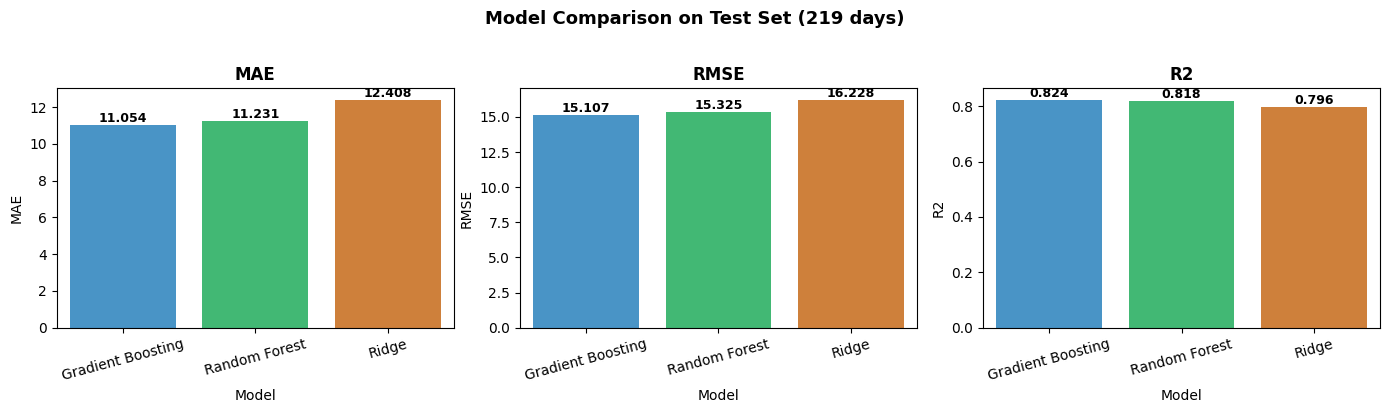

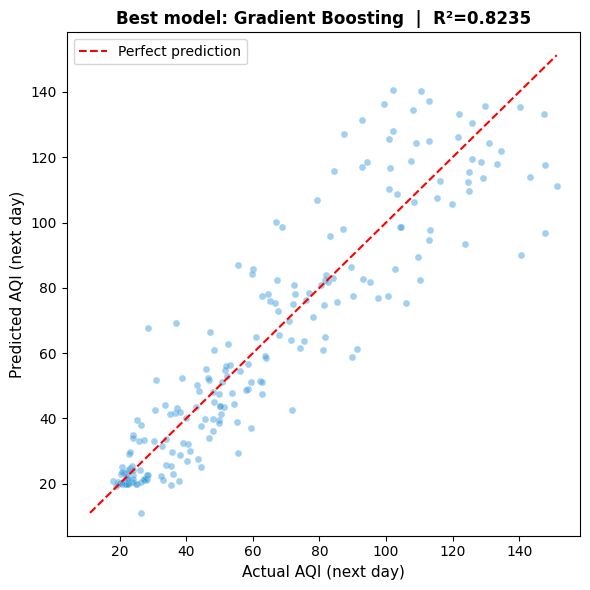

In [17]:
# ── Formatted per-model metric table ─────────────────────────────────────
print("=" * 55)
print(f"{'Model':<22} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 55)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<22} {row['MAE']:>8.3f} {row['RMSE']:>8.3f} {row['R2']:>8.4f}")
print("=" * 55)

best_model = results_df.iloc[0]['Model']
best_row   = results_df.iloc[0]
print(f"\n✅ Best Model  : {best_model}")
print(f"   MAE         : {best_row['MAE']:.3f}  (avg AQI units off)")
print(f"   RMSE        : {best_row['RMSE']:.3f}  (penalises large errors more)")
print(f"   R²          : {best_row['R2']:.4f} (1.0 = perfect, 0 = baseline mean)")

# ── Bar-chart comparison ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
palette = ["#3498db", "#2ecc71", "#e67e22"]

for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    plot_df = results_df.sort_values(metric, ascending=(metric != "R2"))
    sns.barplot(data=plot_df, x="Model", y=metric, ax=ax,
                palette=palette, hue="Model", legend=False)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.tick_params(axis="x", rotation=15)
    for bar in ax.patches:
        ax.annotate(
            f'{bar.get_height():.3f}',
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

plt.suptitle("Model Comparison on Test Set (219 days)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Actual vs Predicted scatter (best model) ──────────────────────────────
best_preds = predictions[best_model]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, best_preds, alpha=0.45, s=25,
           edgecolors='white', linewidth=0.3, color='#3498db')
lims = [min(y_test.min(), best_preds.min()),
        max(y_test.max(), best_preds.max())]
ax.plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
ax.set_xlabel("Actual AQI (next day)", fontsize=11)
ax.set_ylabel("Predicted AQI (next day)", fontsize=11)
ax.set_title(f"Best model: {best_model}  |  R²={best_row['R2']:.4f}",
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
import joblib

# 1. Finalize the Champion Pipeline
champion_model = RandomForestRegressor(n_estimators=200, random_state=42)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', champion_model)
])

# 2. Train on FULL data (Train + Test)
final_pipeline.fit(X, y)

# 3. Save to disk
joblib.dump(final_pipeline, 'aqi_forecast_model.pkl')
print("Optimal model saved as 'aqi_forecast_model.pkl'")

Optimal model saved as 'aqi_forecast_model.pkl'


### Sanity check
checing if model can recursively predict realistic values for the next 3 days timeline

In [19]:
def test_recursive_forecast(test_idx, steps=3):
    # 1. Get the 'Current Day' (the last day the model knows)
    current_day_input = X_test.iloc[[test_idx]]
    
    # 2. Get the 'Future Weather' (the real weather that happened)
    # We grab the weather for the next 3 days from the test set
    future_weather = X_test.iloc[test_idx+1 : test_idx+1+steps]
    
    # 3. Get the 'Ground Truth' (what actually happened to AQI)
    actual_future = y_test.iloc[test_idx : test_idx+steps].values
    
    # 4. Perform Recursive Prediction
    forecast = []
    current_input = current_day_input.copy()
    
    # Use the model within the pipeline we defined earlier
    for i in range(steps):
        # Update weather inputs for the forecast day
        for col in ['temp_max', 'temp_min', 'wind_speed_max']:
            current_input[col] = future_weather.iloc[i][col]
            
        # Predict
        pred = final_pipeline.predict(current_input)[0]
        forecast.append(pred)
        
        # Prepare for next recursion
        current_input['us_aqi_lag_1d'] = pred
        
    return forecast, actual_future

# Run the test on a random index from our test set
test_idx = 10 
forecast, actual = test_recursive_forecast(test_idx)

print(f"Sanity Check starting on: {X_test.iloc[test_idx].name}")
print(f"Forecasted AQI (T+1, T+2, T+3): {np.round(forecast, 2)}")
print(f"Actual AQI (T+1, T+2, T+3):    {np.round(actual, 2)}")

Sanity Check starting on: 885
Forecasted AQI (T+1, T+2, T+3): [82.12 84.57 83.52]
Actual AQI (T+1, T+2, T+3):    [100.5  105.96  89.33]
